In [1]:
# =============================================================================
# Online Retail Dataset - Exploratory Data Analysis (EDA)
# =============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set plotting style
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)


In [ ]:
# =============================================================================
# 1. Load the Dataset
# =============================================================================

file_path = r"C:\Users\morit\Downloads\Online Retail.csv" 

df = pd.read_csv(file_path, encoding='latin1')

print(f"Dataset shape: {df.shape}")
print("\nFirst 5 rows:")
display(df.head())

print("\nDataFrame Info:")
df.info()

Dataset shape: (541909, 8)

First 5 rows:


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom



DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [3]:
# =============================================================================
# 2. Initial Missing Values Check
# =============================================================================

print("\nMissing values per column:")
print(df.isna().sum().sort_values(ascending=False))


Missing values per column:
CustomerID     135080
Description      1454
StockCode           0
InvoiceNo           0
Quantity            0
InvoiceDate         0
UnitPrice           0
Country             0
dtype: int64


In [4]:
# =============================================================================
# 3. Data Cleaning
# =============================================================================

print(f"\nOriginal number of rows: {len(df):,}")

# Remove rows without CustomerID (essential for customer analysis)
df = df[df['CustomerID'].notna()].copy()

# Convert CustomerID to integer (for cleaner handling)
df['CustomerID'] = df['CustomerID'].astype(int)

print(f"Rows after removing missing CustomerID: {len(df):,}")
print(f"Remaining missing CustomerIDs: {df['CustomerID'].isna().sum()}")

# Remove invalid transactions (negative or zero quantity and unit price)
df = df[
    (df['Quantity'] > 0) &
    (df['UnitPrice'] > 0)
].copy()

print(f"Final shape after cleaning: {df.shape}")
print(f"Negative quantities remaining: {(df['Quantity'] < 0).sum()}")
print(f"Zero or negative prices remaining: {(df['UnitPrice'] <= 0).sum()}")


Original number of rows: 541,909
Rows after removing missing CustomerID: 406,829
Remaining missing CustomerIDs: 0
Final shape after cleaning: (397884, 8)
Negative quantities remaining: 0
Zero or negative prices remaining: 0


In [5]:
# =============================================================================
# 4. Feature Engineering
# =============================================================================

# Parse InvoiceDate as datetime
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Create useful derived columns
df['Revenue'] = df['Quantity'] * df['UnitPrice']
df['Month']   = df['InvoiceDate'].dt.to_period('M')
df['Weekday'] = df['InvoiceDate'].dt.day_name()
df['Hour']    = df['InvoiceDate'].dt.hour

print("\nFeature engineering completed. New columns added: Revenue, Month, Weekday, Hour")



Feature engineering completed. New columns added: Revenue, Month, Weekday, Hour


In [6]:
# =============================================================================
# 5. Basic Overview & Cardinality
# =============================================================================

print("\n=== Basic Overview ===")
print(f"Number of unique invoices:     {df['InvoiceNo'].nunique():,}")
print(f"Number of unique customers:    {df['CustomerID'].nunique():,}")
print(f"Number of unique products:     {df['StockCode'].nunique():,}")
print(f"Number of countries:           {df['Country'].nunique()}")

print("\nUnique values per column:")
print(df.nunique().sort_values(ascending=False))


=== Basic Overview ===
Number of unique invoices:     18,532
Number of unique customers:    4,338
Number of unique products:     3,665
Number of countries:           37

Unique values per column:
InvoiceNo      18532
InvoiceDate    17282
CustomerID      4338
Description     3877
StockCode       3665
Revenue         2939
UnitPrice        440
Quantity         301
Country           37
Hour              15
Month             13
Weekday            6
dtype: int64


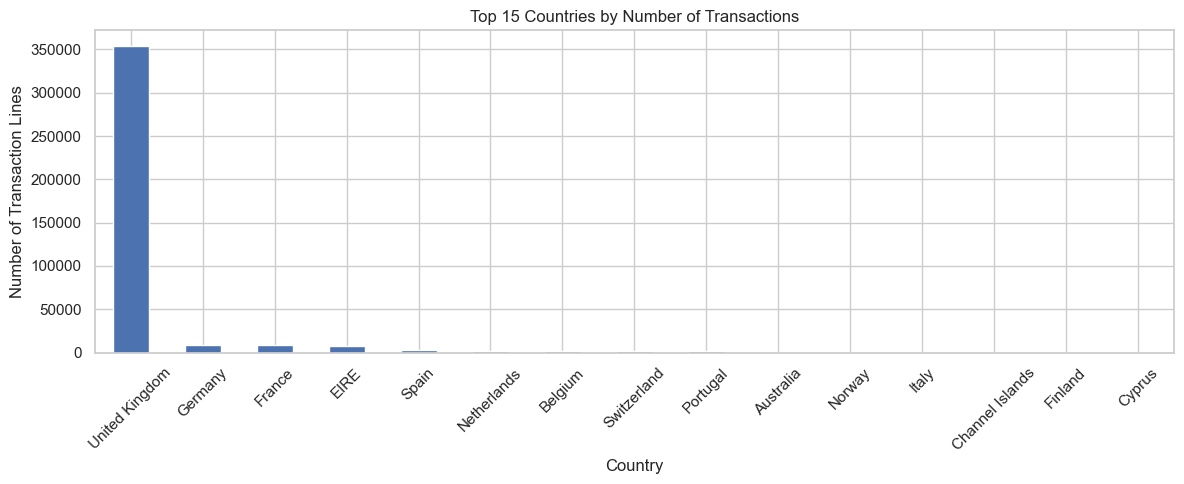


Top 10 countries by revenue share (%):
Country
United Kingdom    82.0
Netherlands        3.2
EIRE               3.0
Germany            2.6
France             2.3
Australia          1.6
Spain              0.7
Switzerland        0.6
Belgium            0.5
Sweden             0.4
Name: Revenue, dtype: float64


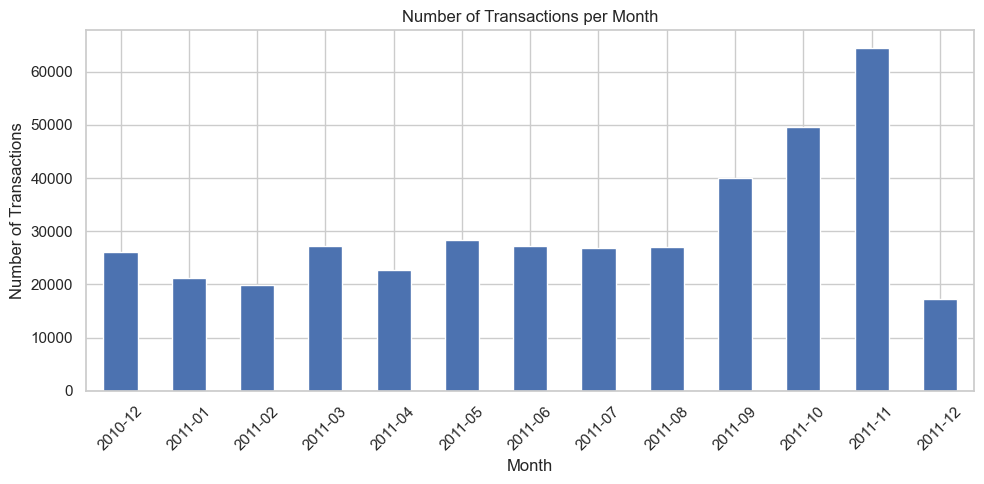

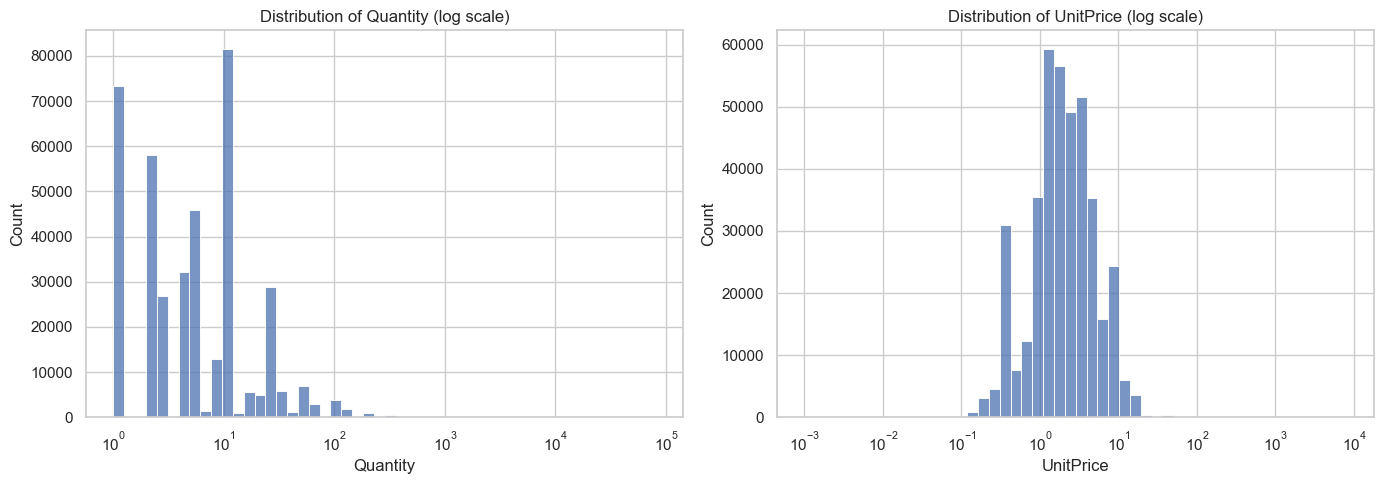


Descriptive statistics - Quantity & UnitPrice:
            Quantity      UnitPrice
count  397884.000000  397884.000000
mean       12.988238       3.116488
std       179.331775      22.097877
min         1.000000       0.001000
1%          1.000000       0.210000
5%          1.000000       0.420000
25%         2.000000       1.250000
50%         6.000000       1.950000
75%        12.000000       3.750000
95%        36.000000       8.500000
99%       120.000000      14.950000
max     80995.000000    8142.750000


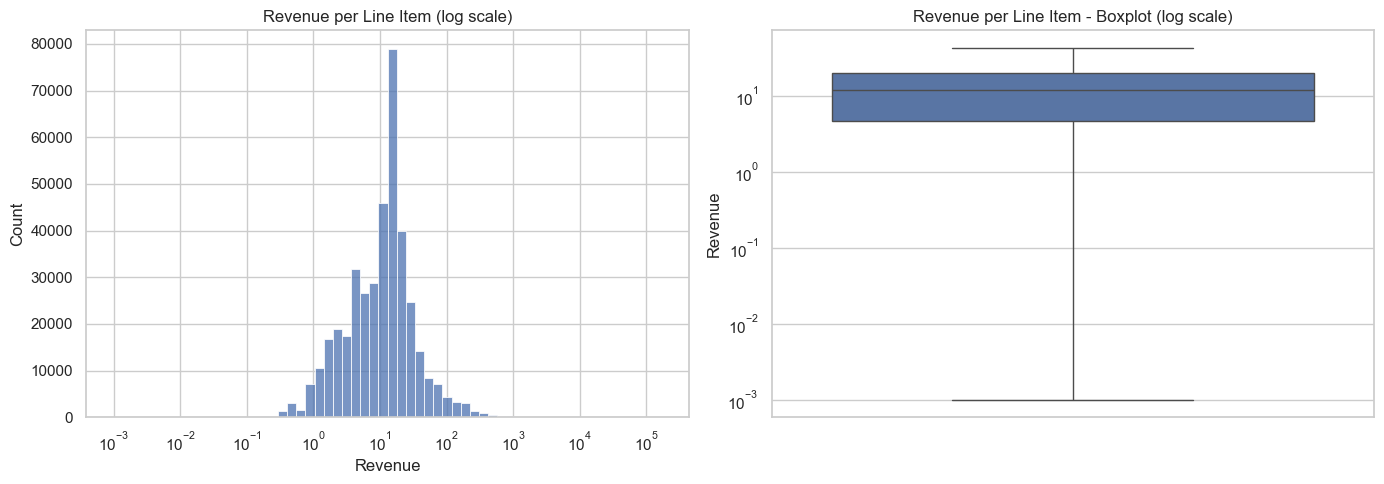


Descriptive statistics - Revenue per line:
count    397884.000000
mean         22.397000
std         309.071041
min           0.001000
1%            0.550000
5%            1.250000
25%           4.680000
50%          11.800000
75%          19.800000
95%          67.500000
99%         202.500000
max      168469.600000
Name: Revenue, dtype: float64


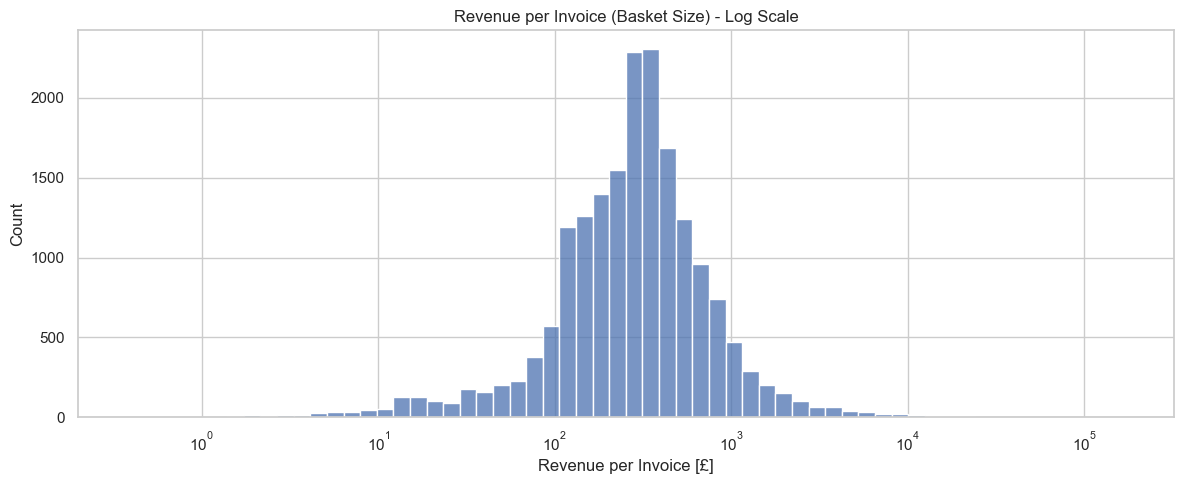


Descriptive statistics - Revenue per Invoice:
count     18532.000000
mean        480.865956
std        1678.195579
min           0.380000
1%            8.500000
5%           38.200000
25%         158.037500
50%         303.040000
75%         471.840000
95%        1236.592500
99%        3849.021400
max      168469.600000
Name: Revenue, dtype: float64


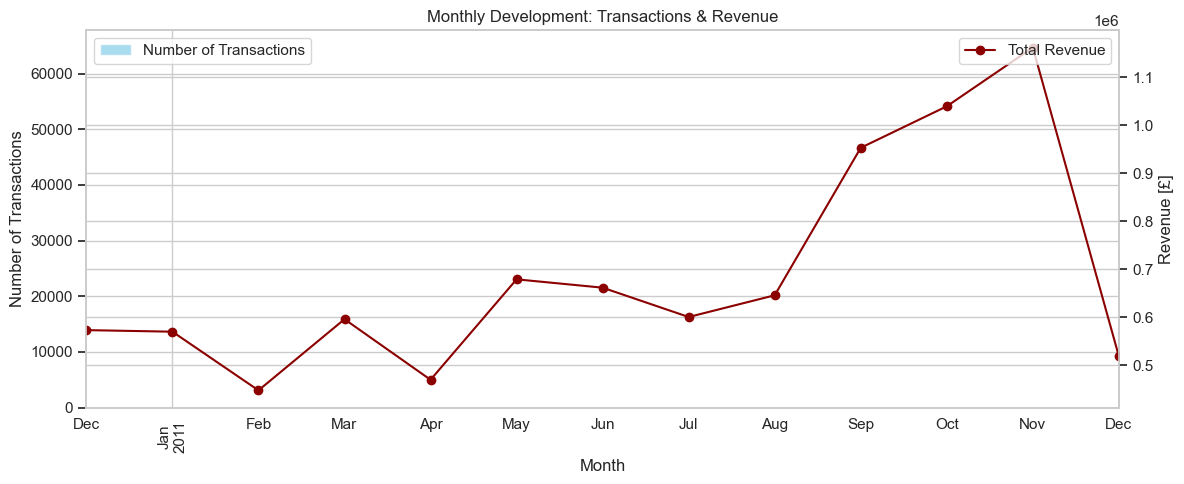

C:\Users\morit\AppData\Local\Temp\ipykernel_11476\2139015152.py:96: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Weekday', order=weekday_order, palette='viridis')


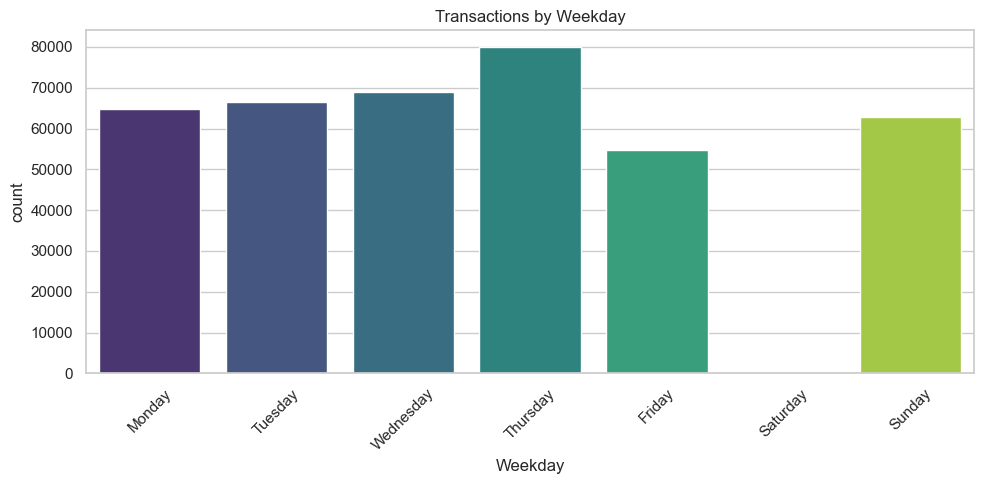

C:\Users\morit\AppData\Local\Temp\ipykernel_11476\2139015152.py:103: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Hour', palette='mako')


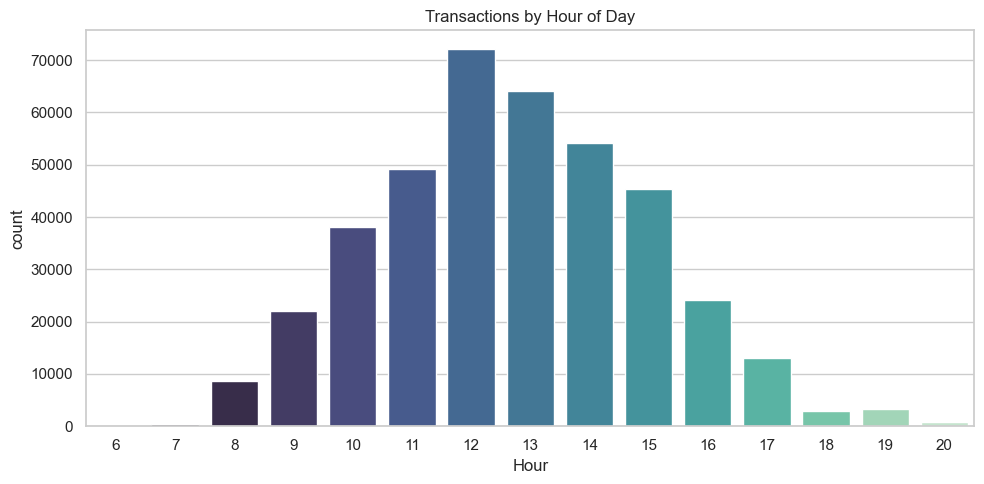


EDA completed successfully!


In [7]:
# =============================================================================
# 6. Exploratory Visualizations
# =============================================================================

# 6.1 Top 15 Countries by number of transactions
plt.figure(figsize=(12, 5))
df['Country'].value_counts().head(15).plot(kind='bar')
plt.title("Top 15 Countries by Number of Transactions")
plt.ylabel("Number of Transaction Lines")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 6.2 Revenue share of top countries
revenue_by_country = df.groupby('Country')['Revenue'].sum().sort_values(ascending=False)
print("\nTop 10 countries by revenue share (%):")
print((revenue_by_country / revenue_by_country.sum() * 100).head(10).round(1))

# 6.3 Transactions per Month
plt.figure(figsize=(10, 5))
df['Month'].value_counts().sort_index().plot(kind='bar')
plt.title("Number of Transactions per Month")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 6.4 Distribution of Quantity and UnitPrice (log scale)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(data=df, x='Quantity', bins=50, log_scale=True, ax=axes[0])
axes[0].set_title("Distribution of Quantity (log scale)")

sns.histplot(data=df, x='UnitPrice', bins=50, log_scale=True, ax=axes[1])
axes[1].set_title("Distribution of UnitPrice (log scale)")

plt.tight_layout()
plt.show()

# Descriptive statistics for Quantity and UnitPrice
print("\nDescriptive statistics - Quantity & UnitPrice:")
print(df[['Quantity', 'UnitPrice']].describe([0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]))

# 6.5 Revenue per transaction line
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(data=df[df['Revenue'] > 0], x='Revenue', bins=60, log_scale=True, ax=axes[0])
axes[0].set_title("Revenue per Line Item (log scale)")

sns.boxplot(data=df[df['Revenue'] > 0], y='Revenue', showfliers=False, ax=axes[1])
axes[1].set_title("Revenue per Line Item - Boxplot (log scale)")
axes[1].set_yscale('log')

plt.tight_layout()
plt.show()

print("\nDescriptive statistics - Revenue per line:")
print(df['Revenue'].describe([0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]))

# 6.6 Revenue per Invoice (Basket Size)
revenue_per_invoice = df.groupby('InvoiceNo')['Revenue'].sum()

plt.figure(figsize=(12, 5))
sns.histplot(revenue_per_invoice[revenue_per_invoice > 0], bins=60, log_scale=True)
plt.title("Revenue per Invoice (Basket Size) - Log Scale")
plt.xlabel("Revenue per Invoice [£]")
plt.tight_layout()
plt.show()

print("\nDescriptive statistics - Revenue per Invoice:")
print(revenue_per_invoice[revenue_per_invoice > 0].describe([0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]))

# 6.7 Monthly Transactions + Revenue
fig, ax1 = plt.subplots(figsize=(12, 5))

monthly_counts = df['Month'].value_counts().sort_index()
monthly_revenue = df.groupby('Month')['Revenue'].sum()

monthly_counts.plot(kind='bar', ax=ax1, color='skyblue', alpha=0.7, label='Number of Transactions')
ax1.set_ylabel('Number of Transactions')
ax1.legend(loc='upper left')

ax2 = ax1.twinx()
monthly_revenue.plot(kind='line', marker='o', color='darkred', ax=ax2, label='Total Revenue')
ax2.set_ylabel('Revenue [£]')
ax2.legend(loc='upper right')

plt.title("Monthly Development: Transactions & Revenue")
plt.tight_layout()
plt.show()

# 6.8 Weekday & Hour Analysis
weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='Weekday', order=weekday_order, palette='viridis')
plt.title("Transactions by Weekday")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='Hour', palette='mako')
plt.title("Transactions by Hour of Day")
plt.xlabel("Hour")
plt.tight_layout()
plt.show()

print("\nEDA completed successfully!")

In [11]:
# =============================================================================
# 7. Save Cleaned Dataset
# =============================================================================

output_path = r"C:\Users\morit\Downloads\cleaned_online_retail.csv"

df.to_csv(output_path, index=False, encoding='utf-8')
print(f"✅ Saved to: {output_path}")

✅ Saved to: C:\Users\morit\Downloads\cleaned_online_retail.csv
